In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return x**3 - x - 2

x0 = 1
x1 = 2

tolerance = 0.000001
max_iterations = 100

In [3]:
iterations = []
roots = []
function_values = []
absolute_errors = []
relative_errors = []

for i in range(1, max_iterations + 1):

    f0 = f(x0)
    f1 = f(x1)

    # Check denominator
    if f1 - f0 == 0:
        print("Division by zero occurred.")
        break

    # Secant formula
    x2 = x1 - f1 * (x1 - x0) / (f1 - f0)

    # Error calculation
    abs_error = abs(x2 - x1)
    rel_error = abs_error / abs(x2)

    iterations.append(i)
    roots.append(x2)
    function_values.append(f(x2))
    absolute_errors.append(abs_error)
    relative_errors.append(rel_error)

    # Check convergence
    if abs_error < tolerance:
        break

    x0 = x1
    x1 = x2

In [4]:
result = pd.DataFrame({
    "Iteration": iterations,
    "x": roots,
    "f(x)": function_values,
    "Absolute Error": absolute_errors,
    "Relative Error": relative_errors
})

print(result.to_string(index=False))

print("\nApproximate Root =", roots[-1])
print("Number of Iterations =", len(iterations))

 Iteration        x          f(x)  Absolute Error  Relative Error
         1 1.333333 -9.629630e-01    6.666667e-01    5.000000e-01
         2 1.462687 -3.333389e-01    1.293532e-01    8.843537e-02
         3 1.531169  5.862642e-02    6.848286e-02    4.472586e-02
         4 1.520926 -2.693300e-03    1.024301e-02    6.734719e-03
         5 1.521376 -2.015019e-05    4.498962e-04    2.957165e-04
         6 1.521380  7.015478e-09    3.391315e-06    2.229105e-06
         7 1.521380 -1.842970e-14    1.180307e-09    7.758137e-10

Approximate Root = 1.5213797068045645
Number of Iterations = 7


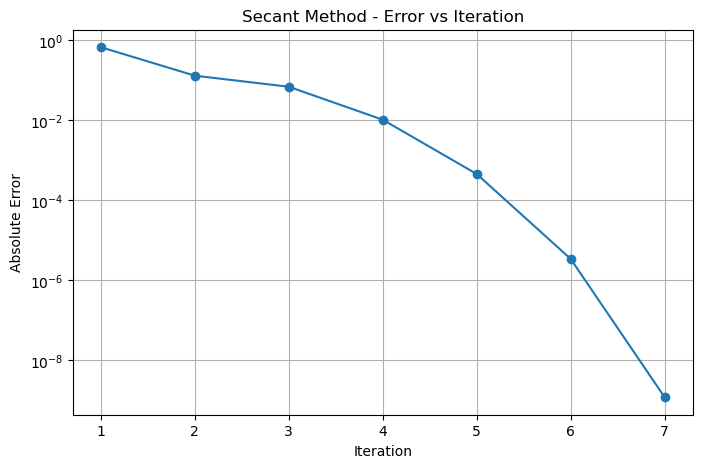

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    iterations,
    absolute_errors,
    marker='o'
)

plt.yscale('log')

plt.xlabel("Iteration")
plt.ylabel("Absolute Error")
plt.title("Secant Method - Error vs Iteration")

plt.grid(True)

plt.show()

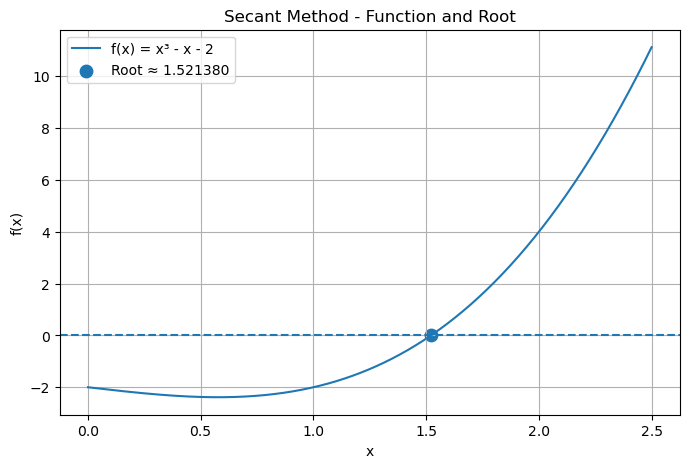

In [ ]:
x_values = np.linspace(0, 2.5, 500)
y_values = f(x_values)

root = roots[-1]

plt.figure(figsize=(8, 5))

plt.plot(
    x_values,
    y_values,
    label="f(x) = x³ - x - 2"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.scatter(
    root,
    f(root),
    s=80,
    label=f"Root ≈ {root:.6f}"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Secant Method - Function and Root")

plt.legend()
plt.grid(True)

plt.show()